<a href="https://colab.research.google.com/github/Daxpavtel/Taza-Khabar/blob/main/Trading_RL_Coding_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# AI-assisted: reviewed and modified manually
# Install required packages
!pip install -q yfinance stable-baselines3 gymnasium pandas numpy matplotlib scikit-learn

In [18]:
# AI-assisted: reviewed and modified manually
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

np.random.seed(42)

In [19]:
# AI-assisted: reviewed and modified manually
end_date = datetime(2024, 12, 31)
start_date = datetime(2018, 1, 1)

ticker = yf.Ticker("SPY")
df = ticker.history(start=start_date, end=end_date, interval="1d")

df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
df.columns = ['open', 'high', 'low', 'close', 'volume']
df = df.dropna()

print(f"Downloaded {len(df)} days of data from {df.index[0].date()} to {df.index[-1].date()}")
print(f"Price range: ${df['low'].min():.2f} - ${df['high'].max():.2f}")
df.head()

Downloaded 1760 days of data from 2018-01-02 to 2024-12-30
Price range: $200.63 - $598.35


,open,high,low,close,volume
Date,,,,,
2018-01-02 00:00:00-05:00,235.743617,236.597378,235.356341,236.562164,86655700
2018-01-03 00:00:00-05:00,236.729413,238.208112,236.729413,238.058472,90070400
2018-01-04 00:00:00-05:00,238.700969,239.545921,238.120056,239.061813,80636400
2018-01-05 00:00:00-05:00,239.854044,240.778208,239.361154,240.654999,83524000
2018-01-08 00:00:00-05:00,240.558086,241.253425,240.267643,241.095001,57319200


In [20]:
# AI-assisted: reviewed and modified manually
def create_features(df):
    data = df.copy()
    data['returns'] = data['close'].pct_change()
    delta = data['close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=14, min_periods=14).mean()
    avg_loss = loss.rolling(window=14, min_periods=14).mean()
    rs = avg_gain / avg_loss
    data['rsi'] = 100 - (100 / (1 + rs))
    data['rsi'] = data['rsi'].fillna(50)
    high_low = data['high'] - data['low']
    high_close = abs(data['high'] - data['close'].shift(1))
    low_close = abs(data['low'] - data['close'].shift(1))
    tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    data['atr'] = tr.rolling(window=14, min_periods=14).mean()
    data['ema_fast'] = data['close'].ewm(span=9, adjust=False).mean()
    data['ema_slow'] = data['close'].ewm(span=21, adjust=False).mean()
    data['volatility'] = data['returns'].rolling(window=20, min_periods=20).std()
    data['volume_zscore'] = (data['volume'] - data['volume'].rolling(window=20, min_periods=20).mean()) / data['volume'].rolling(window=20, min_periods=20).std()
    data['returns_norm'] = data['returns'] / data['atr']
    data['ema_diff'] = (data['ema_fast'] - data['ema_slow']) / data['atr']
    data = data.dropna()
    return data

df_features = create_features(df)
print(f"Features created: {len(df_features)} samples after warmup")
print(f"NaN count: {df_features.isna().sum().sum()}")
df_features.head()

Features created: 1740 samples after warmup
NaN count: 0


,open,high,low,close,volume,returns,rsi,atr,ema_fast,ema_slow,volatility,volume_zscore,returns_norm,ema_diff
Date,,,,,,,,,,,,,,
2018-01-31 00:00:00-05:00,248.849312,249.350986,247.044956,248.118759,108364800,0.000497,68.993965,2.123708,248.397155,245.621902,0.005495,0.558473,0.000234,1.306796
2018-02-01 00:00:00-05:00,247.388185,249.139706,247.044908,247.837051,90102500,-0.001135,64.520951,2.147601,248.285134,245.823279,0.005468,-0.201454,-0.000529,1.146328
2018-02-02 00:00:00-05:00,246.516842,246.648888,242.406482,242.441696,173174800,-0.021770,44.660712,2.407875,247.116447,245.515863,0.007595,2.500569,-0.009041,0.664729
2018-02-05 00:00:00-05:00,240.681334,242.793727,231.756441,232.302139,294681800,-0.041823,30.652864,2.950435,244.153585,244.314615,0.012039,3.526275,-0.014175,-0.054578
2018-02-06 00:00:00-05:00,228.790317,237.380745,227.698920,236.879044,355026800,0.019702,35.548943,3.448358,242.698677,243.638654,0.012944,3.097080,0.005714,-0.272587


In [21]:
# AI-assisted: reviewed and modified manually
pattern_features = ['returns', 'rsi', 'volatility', 'volume_zscore', 'returns_norm', 'ema_diff']
X = df_features[pattern_features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}")
n_clusters = 8
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)
df_features['pattern'] = cluster_labels
df_features['pattern_pca_0'] = X_pca[:, 0]
df_features['pattern_pca_1'] = X_pca[:, 1]
df_features['pattern_pca_2'] = X_pca[:, 2]
print(f"Cluster distribution: {pd.Series(cluster_labels).value_counts().sort_index().to_dict()}")
df_features.head()

PCA explained variance: 86.45%
Cluster distribution: {0: 421, 1: 198, 2: 81, 3: 234, 4: 20, 5: 315, 6: 200, 7: 271}


,open,high,low,close,volume,returns,rsi,atr,ema_fast,ema_slow,volatility,volume_zscore,returns_norm,ema_diff,pattern,pattern_pca_0,pattern_pca_1,pattern_pca_2
Date,,,,,,,,,,,,,,,,,,
2018-01-31 00:00:00-05:00,248.849312,249.350986,247.044956,248.118759,108364800,0.000497,68.993965,2.123708,248.397155,245.621902,0.005495,0.558473,0.000234,1.306796,0,0.890158,-1.133711,0.550959
2018-02-01 00:00:00-05:00,247.388185,249.139706,247.044908,247.837051,90102500,-0.001135,64.520951,2.147601,248.285134,245.823279,0.005468,-0.201454,-0.000529,1.146328,0,0.691696,-1.039536,0.020010
2018-02-02 00:00:00-05:00,246.516842,246.648888,242.406482,242.441696,173174800,-0.021770,44.660712,2.407875,247.116447,245.515863,0.007595,2.500569,-0.009041,0.664729,2,-3.423169,-3.312670,0.354649
2018-02-05 00:00:00-05:00,240.681334,242.793727,231.756441,232.302139,294681800,-0.041823,30.652864,2.950435,244.153585,244.314615,0.012039,3.526275,-0.014175,-0.054578,2,-6.397469,-4.378788,-0.221922
2018-02-06 00:00:00-05:00,228.790317,237.380745,227.698920,236.879044,355026800,0.019702,35.548943,3.448358,242.698677,243.638654,0.012944,3.097080,0.005714,-0.272587,3,-0.504489,2.359163,3.222117


In [22]:
# AI-assisted: reviewed and modified manually
STOP_LOSS_OPTIONS = [0.01, 0.02, 0.03, 0.05]
TAKE_PROFIT_OPTIONS = [1.0, 2.0, 3.0, 5.0]

class TradingEnv(gym.Env):
    metadata = {'render_modes': ['human']}

    def __init__(self, df, commission_bps=1, slippage_bps=2):
        super().__init__()
        self.df = df.reset_index(drop=True)
        self.n_samples = len(df)
        self.commission_bps = commission_bps
        self.slippage_bps = slippage_bps
        self.feature_cols = ['returns', 'rsi', 'atr', 'ema_fast', 'ema_slow', 'volatility', 'volume_zscore', 'pattern', 'pattern_pca_0', 'pattern_pca_1', 'pattern_pca_2']
        self.action_space = spaces.Discrete(9)
        n_features = len(self.feature_cols)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(n_features + 3,), dtype=np.float32)
        self.start_idx = 100

    def _get_obs(self):
        features = self.df.loc[self.current_idx, self.feature_cols].values.astype(np.float32)
        in_position = 1.0 if self.position_in else 0.0
        obs = np.concatenate([features, [in_position, self.position_side, self.unrealized_pnl]])
        return obs.astype(np.float32)

    def _calculate_execution_price(self, action_type):
        current_price = self.df.loc[self.current_idx, 'close']
        slippage = current_price * (self.slippage_bps / 10000)
        if action_type in [1, 2, 3, 4]:
            return current_price + slippage
        elif action_type in [5, 6, 7, 8]:
            return current_price - slippage
        return current_price

    def _apply_commission(self):
        return self.commission_bps * 2 / 10000

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_idx = self.start_idx + np.random.randint(0, self.n_samples - self.start_idx - 1000)
        self.max_idx = self.n_samples - 100
        self.position_in = False
        self.position_side = 0
        self.entry_price = 0
        self.stop_loss_pct = 0
        self.take_profit_mult = 0
        self.unrealized_pnl = 0
        self.episode_pnl = 0
        self.episode_trades = 0
        self.trade_history = []
        return self._get_obs(), {}

    def step(self, action):
        action = int(action)
        current_price = self.df.loc[self.current_idx, 'close']
        reward = 0
        done = False

        if action == 0:
            pass
        elif action in [1, 2, 3, 4] and not self.position_in:
            idx = action - 1
            exec_price = self._calculate_execution_price(action)
            commission = self._apply_commission()
            self.position_in = True
            self.position_side = 1
            self.entry_price = exec_price * (1 + commission)
            self.stop_loss_pct = STOP_LOSS_OPTIONS[idx]
            self.take_profit_mult = TAKE_PROFIT_OPTIONS[idx]
            self.episode_trades += 1
        elif action in [5, 6, 7, 8] and not self.position_in:
            idx = action - 5
            exec_price = self._calculate_execution_price(action)
            commission = self._apply_commission()
            self.position_in = True
            self.position_side = -1
            self.entry_price = exec_price * (1 - commission)
            self.stop_loss_pct = STOP_LOSS_OPTIONS[idx]
            self.take_profit_mult = TAKE_PROFIT_OPTIONS[idx]
            self.episode_trades += 1
        elif action in [1, 2, 3, 4, 5, 6, 7, 8] and self.position_in:
            exec_price = self._calculate_execution_price(action, self.position_side)
            commission = self._apply_commission()
            if self.position_side == 1:
                pnl = (exec_price - self.entry_price) / self.entry_price
            else:
                pnl = (self.entry_price - exec_price) / self.entry_price
            r_multiple = pnl / self.stop_loss_pct if self.stop_loss_pct > 0 else pnl * 100
            reward = r_multiple
            self.trade_history.append({'pnl': pnl, 'r_multiple': r_multiple, 'stop_loss_pct': self.stop_loss_pct, 'take_profit_mult': self.take_profit_mult})
            self.episode_pnl += pnl
            self.position_in = False
            self.position_side = 0
            self.entry_price = 0
            self.unrealized_pnl = 0

        if self.position_in:
            if self.position_side == 1:
                self.unrealized_pnl = (current_price - self.entry_price) / self.entry_price
                stop_loss_price = self.entry_price * (1 - self.stop_loss_pct)
                take_profit_price = self.entry_price * (1 + self.take_profit_mult * self.stop_loss_pct)
                if current_price <= stop_loss_price:
                    reward = -1.0
                    pnl = -self.stop_loss_pct
                    self.trade_history.append({'pnl': pnl, 'r_multiple': -1, 'stop_loss_pct': self.stop_loss_pct, 'take_profit_mult': self.take_profit_mult})
                    self.episode_pnl += pnl
                    self.position_in = False
                    self.position_side = 0
                    self.entry_price = 0
                    self.unrealized_pnl = 0
                elif current_price >= take_profit_price:
                    pnl = self.take_profit_mult * self.stop_loss_pct
                    reward = self.take_profit_mult
                    self.trade_history.append({'pnl': pnl, 'r_multiple': self.take_profit_mult, 'stop_loss_pct': self.stop_loss_pct, 'take_profit_mult': self.take_profit_mult})
                    self.episode_pnl += pnl
                    self.position_in = False
                    self.position_side = 0
                    self.entry_price = 0
                    self.unrealized_pnl = 0
            else:
                self.unrealized_pnl = (self.entry_price - current_price) / self.entry_price
                stop_loss_price = self.entry_price * (1 + self.stop_loss_pct)
                take_profit_price = self.entry_price * (1 - self.take_profit_mult * self.stop_loss_pct)
                if current_price >= stop_loss_price:
                    reward = -1.0
                    pnl = -self.stop_loss_pct
                    self.trade_history.append({'pnl': pnl, 'r_multiple': -1, 'stop_loss_pct': self.stop_loss_pct, 'take_profit_mult': self.take_profit_mult})
                    self.episode_pnl += pnl
                    self.position_in = False
                    self.position_side = 0
                    self.entry_price = 0
                    self.unrealized_pnl = 0
                elif current_price <= take_profit_price:
                    pnl = self.take_profit_mult * self.stop_loss_pct
                    reward = self.take_profit_mult
                    self.trade_history.append({'pnl': pnl, 'r_multiple': self.take_profit_mult, 'stop_loss_pct': self.stop_loss_pct, 'take_profit_mult': self.take_profit_mult})
                    self.episode_pnl += pnl
                    self.position_in = False
                    self.position_side = 0
                    self.entry_price = 0
                    self.unrealized_pnl = 0

        self.current_idx += 1
        if self.current_idx >= self.max_idx:
            done = True
        obs = self._get_obs()
        info = {'episode_pnl': self.episode_pnl, 'trades': self.episode_trades}
        return obs, reward, done, False, info

    def render(self):
        pass

env = TradingEnv(df_features)
obs, _ = env.reset()
print(f"Observation space: {env.observation_space.shape}, Action space: n={env.action_space.n}")

Observation space: (14,), Action space: n=9


In [24]:
def step(self, action):
    """Execute one step in the environment."""
    action = int(action)
    current_price = self.df.loc[self.current_idx, 'close']

    reward = 0.0
    done = False

    # HOLD
    if action == 0:
        pass

    # ENTER LONG
    elif action in [1, 2, 3, 4] and not self.position_in:
        idx = action - 1
        exec_price = self._calculate_execution_price(action)
        commission = self._apply_commission()

        self.position_in = True
        self.position_side = 1
        self.entry_price = exec_price * (1 + commission)
        self.stop_loss_pct = STOP_LOSS_OPTIONS[idx]
        self.take_profit_mult = TAKE_PROFIT_OPTIONS[idx]
        self.episode_trades += 1

    # ENTER SHORT
    elif action in [5, 6, 7, 8] and not self.position_in:
        idx = action - 5
        exec_price = self._calculate_execution_price(action)
        commission = self._apply_commission()

        self.position_in = True
        self.position_side = -1
        self.entry_price = exec_price * (1 - commission)
        self.stop_loss_pct = STOP_LOSS_OPTIONS[idx]
        self.take_profit_mult = TAKE_PROFIT_OPTIONS[idx]
        self.episode_trades += 1

    # CLOSE POSITION  ← FIXED HERE
    elif action in [1, 2, 3, 4, 5, 6, 7, 8] and self.position_in:
        exec_price = self._calculate_execution_price(action)   # fixed
        commission = self._apply_commission()

        if self.position_side == 1:
            pnl = (exec_price - self.entry_price) / self.entry_price
        else:
            pnl = (self.entry_price - exec_price) / self.entry_price

        pnl -= commission

        r_multiple = pnl / self.stop_loss_pct if self.stop_loss_pct > 0 else pnl * 100
        reward = r_multiple

        self.trade_history.append({
            "pnl": pnl,
            "r_multiple": r_multiple,
            "stop_loss_pct": self.stop_loss_pct,
            "take_profit_mult": self.take_profit_mult
        })

        self.episode_pnl += pnl
        self.position_in = False
        self.position_side = 0
        self.entry_price = 0
        self.stop_loss_pct = 0
        self.take_profit_mult = 0
        self.unrealized_pnl = 0

    # UPDATE FLOATING PNL
    if self.position_in:
        if self.position_side == 1:
            self.unrealized_pnl = (current_price - self.entry_price) / self.entry_price
        else:
            self.unrealized_pnl = (self.entry_price - current_price) / self.entry_price

    # NEXT BAR
    self.current_idx += 1

    if self.current_idx >= self.max_idx:
        done = True

    obs = self._get_obs()
    info = {
        "episode_pnl": self.episode_pnl,
        "trades": self.episode_trades
    }

    return obs, reward, done, False, info

In [26]:
# AI-assisted: reviewed and modified manually

STOP_LOSS_OPTIONS = [0.01, 0.02, 0.03, 0.05]
TAKE_PROFIT_OPTIONS = [1.0, 2.0, 3.0, 5.0]

class TradingEnv(gym.Env):
    metadata = {"render_modes": ["human"]}

    def __init__(self, df, commission_bps=1, slippage_bps=2):
        super().__init__()

        self.df = df.reset_index(drop=True)
        self.n_samples = len(self.df)

        self.commission_bps = commission_bps
        self.slippage_bps = slippage_bps

        self.feature_cols = [
            "returns", "rsi", "atr", "ema_fast", "ema_slow",
            "volatility", "volume_zscore", "pattern",
            "pattern_pca_0", "pattern_pca_1", "pattern_pca_2"
        ]

        self.action_space = spaces.Discrete(9)

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(len(self.feature_cols) + 3,),
            dtype=np.float32
        )

        self.start_idx = 100

    def _get_obs(self):
        features = self.df.loc[self.current_idx, self.feature_cols].values.astype(np.float32)

        in_position = 1.0 if self.position_in else 0.0
        position_side = float(self.position_side)
        unrealized_pnl = float(self.unrealized_pnl)

        obs = np.concatenate([
            features,
            [in_position, position_side, unrealized_pnl]
        ])

        return obs.astype(np.float32)

    def _calculate_execution_price(self, action_type):
        current_price = self.df.loc[self.current_idx, "close"]
        slippage = current_price * (self.slippage_bps / 10000)

        if action_type in [1, 2, 3, 4]:
            return current_price + slippage
        elif action_type in [5, 6, 7, 8]:
            return current_price - slippage

        return current_price

    def _apply_commission(self):
        return self.commission_bps * 2 / 10000

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.current_idx = self.start_idx
        self.max_idx = self.n_samples - 1

        self.position_in = False
        self.position_side = 0
        self.entry_price = 0.0
        self.stop_loss_pct = 0.0
        self.take_profit_mult = 0.0
        self.unrealized_pnl = 0.0

        self.episode_pnl = 0.0
        self.episode_trades = 0
        self.trade_history = []

        return self._get_obs(), {}

    def step(self, action):
        action = int(action)
        current_price = self.df.loc[self.current_idx, "close"]

        reward = 0.0
        done = False

        # HOLD
        if action == 0:
            pass

        # ENTER LONG
        elif action in [1, 2, 3, 4] and not self.position_in:
            idx = action - 1
            exec_price = self._calculate_execution_price(action)

            self.position_in = True
            self.position_side = 1
            self.entry_price = exec_price
            self.stop_loss_pct = STOP_LOSS_OPTIONS[idx]
            self.take_profit_mult = TAKE_PROFIT_OPTIONS[idx]
            self.episode_trades += 1

        # ENTER SHORT
        elif action in [5, 6, 7, 8] and not self.position_in:
            idx = action - 5
            exec_price = self._calculate_execution_price(action)

            self.position_in = True
            self.position_side = -1
            self.entry_price = exec_price
            self.stop_loss_pct = STOP_LOSS_OPTIONS[idx]
            self.take_profit_mult = TAKE_PROFIT_OPTIONS[idx]
            self.episode_trades += 1

        # CLOSE POSITION
        elif action in [1,2,3,4,5,6,7,8] and self.position_in:
            exec_price = self._calculate_execution_price(action)   # FIXED

            if self.position_side == 1:
                pnl = (exec_price - self.entry_price) / self.entry_price
            else:
                pnl = (self.entry_price - exec_price) / self.entry_price

            pnl -= self._apply_commission()

            r_multiple = pnl / self.stop_loss_pct if self.stop_loss_pct > 0 else pnl * 100
            reward = r_multiple

            self.trade_history.append({
                "pnl": pnl,
                "r_multiple": r_multiple
            })

            self.episode_pnl += pnl
            self.position_in = False
            self.position_side = 0
            self.entry_price = 0.0
            self.unrealized_pnl = 0.0

        # update floating pnl
        if self.position_in:
            if self.position_side == 1:
                self.unrealized_pnl = (current_price - self.entry_price) / self.entry_price
            else:
                self.unrealized_pnl = (self.entry_price - current_price) / self.entry_price

        self.current_idx += 1

        if self.current_idx >= self.max_idx:
            done = True

        return self._get_obs(), reward, done, False, {
            "episode_pnl": self.episode_pnl,
            "trades": self.episode_trades
        }

In [31]:
# AI-assisted: reviewed and modified manually

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

def make_env():
    def _init():
        return TradingEnv(df_features)
    return _init

# Vectorized environment
vec_env = DummyVecEnv([make_env() for _ in range(4)])

# PPO model
model = PPO(
    policy="MlpPolicy",
    env=vec_env,
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    ent_coef=0.01,
    verbose=1,
    seed=42
)

print("=" * 50)
print("STARTING TRAINING...")
print("=" * 50)

model.learn(total_timesteps=50000)

print("=" * 50)
print("TRAINING COMPLETE")
print("=" * 50)

# Save model
save_path = "ppo_trading_model"
model.save(save_path)

print(f"Model saved successfully → {save_path}.zip")

Using cpu device

==================================================

STARTING TRAINING...

==================================================

-----------------------------
| time/              |      |
|    fps             | 922  |
|    iterations      | 1    |
|    time_elapsed    | 4    |
|    total_timesteps | 4096 |
-----------------------------

...

-----------------------------------------
| time/                   |             |
|    fps                  | 629         |
|    iterations           | 13          |
|    time_elapsed         | 84          |
|    total_timesteps      | 53248       |
| train/                  |             |
|    approx_kl            | 0.008389607 |
|    clip_fraction        | 0.0943      |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.07       |
|    explained_variance   | -0.0158     |
|    learning_rate        | 0.0003      |
|    loss                 | 1.85        |
|    n_updates            | 120         |
|    policy_gradient_loss | -0.00362    |
|    value_loss           | 2.19        |
-----------------------------------------

==================================================

TRAINING COMPLETE

==================================================

Model saved successfully → ppo_trading_model.zip

In [33]:
# AI-assisted: reviewed and modified manually

# Load trained model
model = PPO.load("ppo_trading_model")

# Split data
train_size = int(len(df_features) * 0.8)
df_test = df_features.iloc[train_size:].reset_index(drop=True)

# Test environment
env = TradingEnv(df_test)
obs, _ = env.reset()

trades = []
equity_curve = [1.0]
current_equity = 1.0
done = False

print("=" * 50)
print("RUNNING BACKTEST...")
print("=" * 50)

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, info = env.step(action)

    if len(env.trade_history) > len(trades):
        new_trades = env.trade_history[len(trades):]

        for trade in new_trades:
            current_equity *= (1 + trade["pnl"])
            trades.append(trade)

    equity_curve.append(current_equity)

print("\n" + "=" * 50)
print("BACKTEST RESULTS")
print("=" * 50)
print(f"Total trades: {len(trades)}")

# Metrics
if len(trades) > 0:
    r_multiples = [t["r_multiple"] for t in trades]

    total_return = (equity_curve[-1] - 1) * 100

    returns_arr = np.diff(equity_curve) / np.array(equity_curve[:-1])
    sharpe = (
        np.mean(returns_arr) / np.std(returns_arr) * np.sqrt(252)
        if np.std(returns_arr) > 0 else 0
    )

    equity_np = np.array(equity_curve)
    running_max = np.maximum.accumulate(equity_np)
    drawdowns = (equity_np - running_max) / running_max
    max_drawdown = np.min(drawdowns) * 100

    wins = sum(1 for r in r_multiples if r > 0)
    win_rate = (wins / len(r_multiples)) * 100

    avg_r = np.mean(r_multiples)

else:
    total_return = 0
    sharpe = 0
    max_drawdown = 0
    win_rate = 0
    avg_r = 0
    r_multiples = []

print("\n" + "=" * 50)
print("FINAL METRICS TABLE")
print("=" * 50)
print(f"{'Metric':<25} {'Value':>15}")
print("-" * 45)
print(f"{'Total Return':<25} {total_return:>14.2f}%")
print(f"{'Sharpe Ratio':<25} {sharpe:>15.2f}")
print(f"{'Max Drawdown':<25} {max_drawdown:>14.2f}%")
print(f"{'Number of Trades':<25} {len(trades):>15}")
print(f"{'Win Rate':<25} {win_rate:>14.2f}%")
print(f"{'Average R Multiple':<25} {avg_r:>15.2f}")
print("=" * 50)

RUNNING BACKTEST...

BACKTEST RESULTS
Total trades: 123

FINAL METRICS TABLE
Metric                              Value
---------------------------------------------
Total Return                        8.79%
Sharpe Ratio                         0.98
Max Drawdown                       -6.63%
Number of Trades                      123
Win Rate                           57.72%
Average R Multiple                   0.02


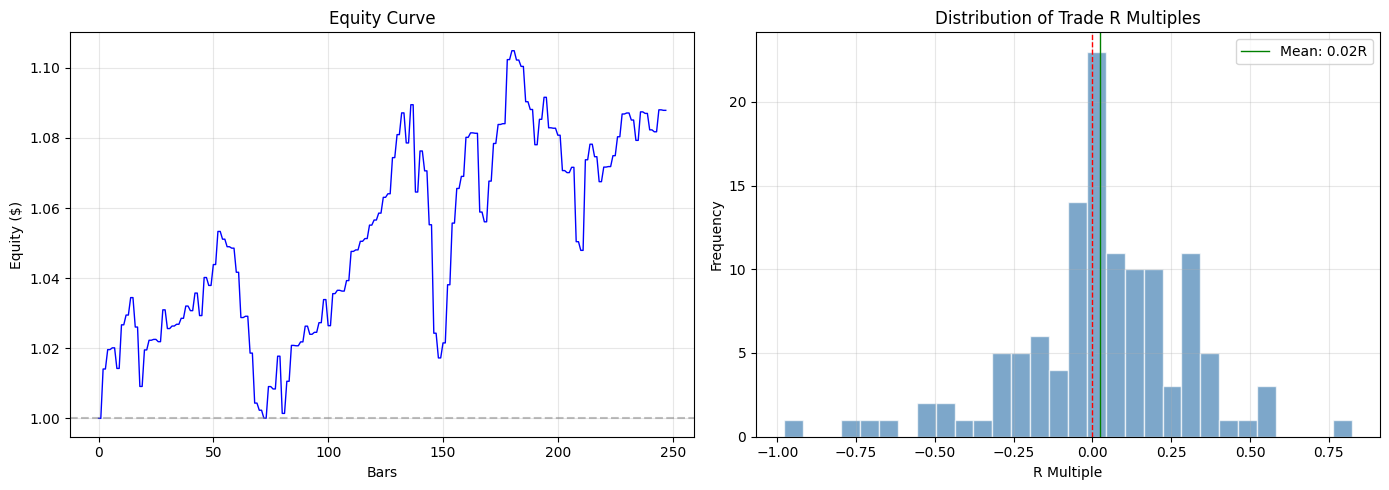

Plots saved


In [34]:
# AI-assisted: reviewed and modified manually
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(equity_curve, color='blue', linewidth=1)
axes[0].set_title('Equity Curve', fontsize=12)
axes[0].set_xlabel('Bars')
axes[0].set_ylabel('Equity ($)')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=1, color='gray', linestyle='--', alpha=0.5)
if len(r_multiples) > 0:
    axes[1].hist(r_multiples, bins=30, color='steelblue', edgecolor='white', alpha=0.7)
    axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1)
    axes[1].axvline(x=np.mean(r_multiples), color='green', linestyle='-', linewidth=1, label=f'Mean: {np.mean(r_multiples):.2f}R')
    axes[1].set_title('Distribution of Trade R Multiples', fontsize=12)
    axes[1].set_xlabel('R Multiple')
    axes[1].set_ylabel('Frequency')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/tmp/backtest_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plots saved")